## Homework 1

# Kavin Kannan 2/28/2025           

Part I: Simulating a fixed length random walk in one dimension (1D).
To start, model a one-dimensional line of points using the position x, where integer values of x
correspond to points on a grid. The tracer particle will start at position x = 0. The rule for the 1D
random walk is simply that at each time step, the particle can choose, with equal probability, to move
one step either to the left, or to the right, after which you update the particle’s x position. This simulates
the particles diffusing back and forth on the line, randomly, for a specified number of steps.

In [25]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng()

A. (5 pts) Write a program that executes one ‘walk’ starting from x = 0 and takes N steps. Create
an instance of the numpy random number generator rng = np.random.default_rng()
and use the method rng.integers() with the appropriate argument. Look at the class notes
or the handout “More Python Features” for guidance in using the numpy random module.

In [ ]:
def randomwalk(N): #Defining a function to generate an array of all movements that a particle makes in N steps.
    random_step = rng.choice([-1,1], size=N) #Choosing one random step either forward or backward by one unit
    cumulative_walk = np.insert(np.cumsum(random_step), 0, 0) #Inserting that step into an array that details all positions of the walk
    return(cumulative_walk) #Returns the array detailing every move that the particle made to end up at its final position

B. (5 pts) Make a plot of the x position of the particle as a function of step number for N = 100 and
1000. Use the matplotlib library. Label the horizontal and vertical axes appropriately and give
the plot a title.

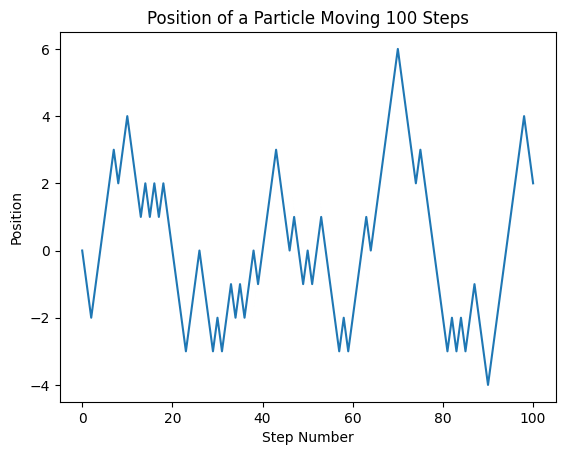

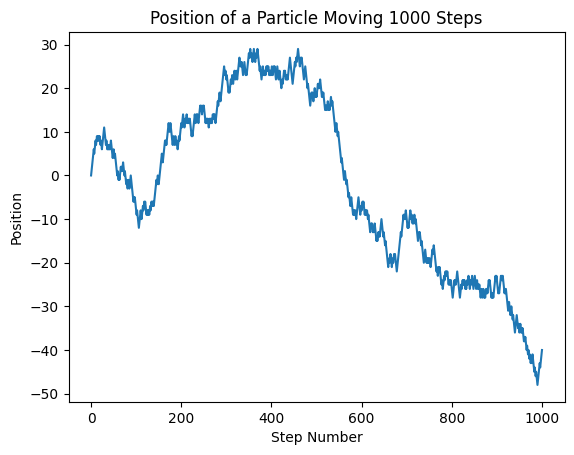

In [105]:
steps100 = randomwalk(100) #Calling the function created in order to generate a random movement of 100 steps
plt.plot(steps100) #Plotting the graph for 100 random steps
plt.xlabel("Step Number")
plt.ylabel("Position")
plt.title("Position of a Particle Moving 100 Steps")
plt.show()

steps1000 = randomwalk(1000) #Calling the function created in order to generate a random movement of 1000 steps
plt.plot(steps1000) #Plotting the graph for 1000 random steps
plt.xlabel("Step Number")
plt.ylabel("Position")
plt.title("Position of a Particle Moving 1000 Steps")
plt.show()

C. (5 pts) Plot 10 separate N-step random walks on the same graph (i.e. number of trials Ntrials =
10) for N = 100 and 1000.

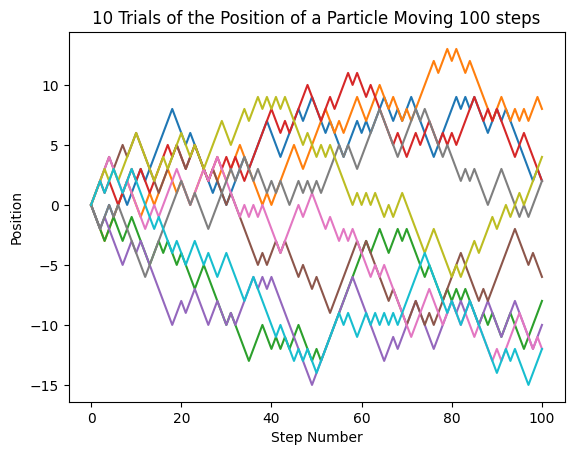

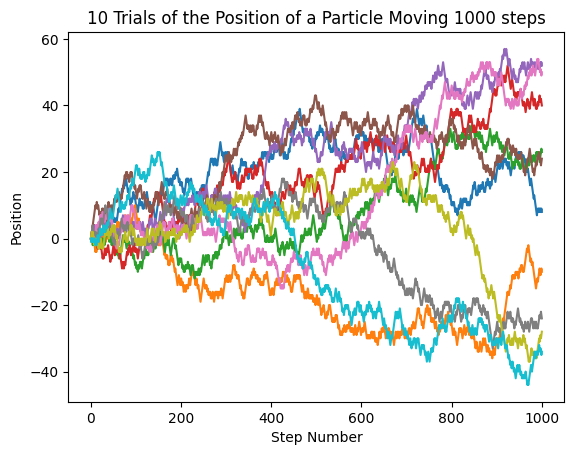

In [106]:
def randomplot(N, Ntrials): #Defining a function to graph all movements of Ntrials trials all taking N steps
    for i in range(Ntrials): #Iterating through each trial in order to plot it on the graph
        newrandomwalk = randomwalk(N)
        plt.plot(newrandomwalk) #Plotting the new trial created by calling the function we created 
    plt.xlabel("Step Number")
    plt.ylabel("Position")
    plt.title(f"{Ntrials} Trials of the Position of a Particle Moving {N} steps")
    plt.show()

randomplot(100, 10)
randomplot(1000, 10)

D. (5 pts) Now stop plotting the x position of the walker vs step number. Instead, run Ntrials = 1000
random walks of N steps, and record the final x position of each separate walk. Do this for N =
100, 104
, 9 x 104
. For each N value, generate a histogram of the final x positions of the walker.
Choose the number of bins judiciously to make your graph look good. What kind of distribution
do you see?

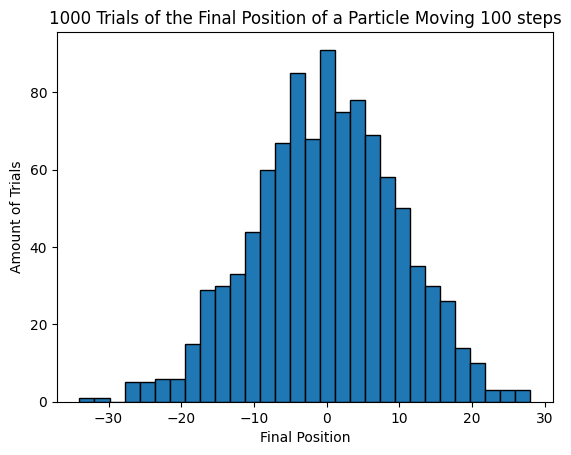

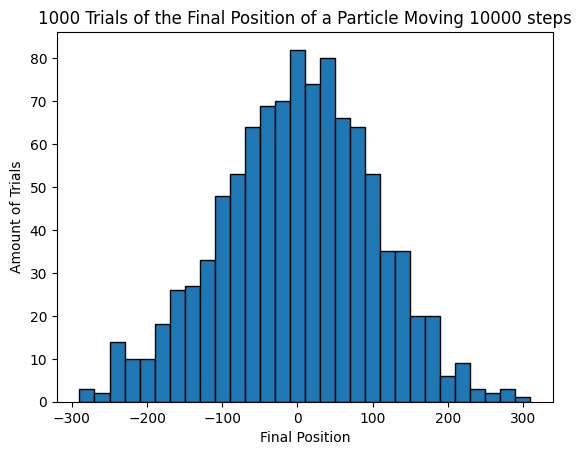

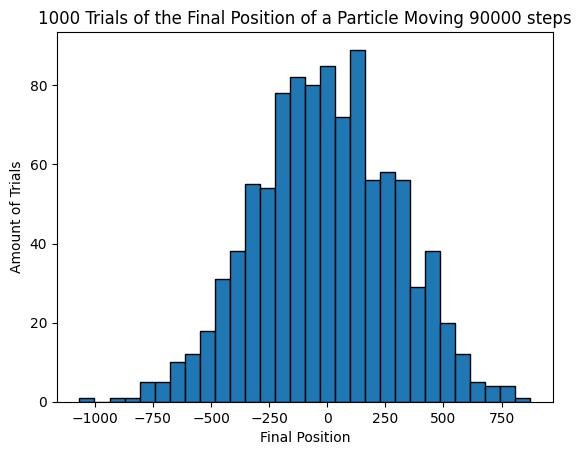

In [107]:
def randomwalkfinalhist(N, Ntrials): #Defining a function to generate the final position of all movements that a particle makes in N steps Ntrials times with a histogram
    allfinalpositions = []
    for trial in range(Ntrials): #Running the randomwalk function from earlier in Ntrials times in order to add the final position to an array of all final positions
        newfinalposition = randomwalk(N)
        allfinalpositions.append(newfinalposition[-1]) #Adding the new final position to the array of all final positions
    plt.figure()
    plt.hist(allfinalpositions, edgecolor='black', linewidth=1, bins=30) #Plotting the histogram of all the final positions
    plt.title(f"{Ntrials} Trials of the Final Position of a Particle Moving {N} steps")
    plt.xlabel("Final Position")
    plt.ylabel("Amount of Trials")
    plt.plot
    return(allfinalpositions) #Returns the array detailing the final positions of all particles

firstanswer = randomwalkfinalhist(100, 1000)
secondanswer = randomwalkfinalhist(10**4, 1000)
thirdanswer = randomwalkfinalhist(9*10**4, 1000)

E. (5 pts) For these three values of N = 100, 104
, 9 x 104
, run Ntrials = 1000 random walks, and
calculate the mean and root mean square (rms) displacement from the origin for each N.

In [116]:
def randomwalkfinal(N, Ntrials): #Using the function created in 1D without the histogram part
    allfinalpositions = []
    for trial in range(Ntrials): #Running the randomwalk function from earlier in Ntrials times in order to add the final position to an array of all final positions
        newfinalposition = randomwalk(N)
        allfinalpositions.append(newfinalposition[-1]) #Adding the new final position to the array of all final positions
    return(allfinalpositions) #Returns the array detailing the final positions of all particles

firstrandomwalk = randomwalkfinal(100,1000) #Getting all the final positions for the 1000 trials of 100 steps
firstanswer = (np.mean(firstrandomwalk)) #Calculating the mean of all final positions
firstanswerrms = (np.sqrt(np.mean(np.square(firstrandomwalk)))) #Calculating the root mean square of all the final positions
print(f"The mean of 100 Steps and 1000 Trials is {firstanswer} with an rms of {firstanswerrms}")

secondrandomwalk = randomwalkfinal(10**4, 1000) #Repeating for 1000 trials and 10000 steps
secondanswer = (np.mean(secondrandomwalk))
secondanswerrms = (np.sqrt(np.mean(np.square(secondrandomwalk))))
print(f"The mean of 10000 Steps and 1000 Trials is {secondanswer} with an rms of {secondanswerrms}")

thirdrandomwalk = randomwalkfinal(9*10**4, 1000) #Repeating for 1000 trials and 90000 steps
thirdanswer = (np.mean(thirdrandomwalk))
thirdanswerrms = (np.sqrt(np.mean(np.square(thirdrandomwalk))))
print(f"The mean of 90000 Steps and 1000 Trials is {thirdanswer} with an rms of {thirdanswerrms}")

The mean of 100 Steps and 1000 Trials is -0.21 with an rms of 9.876234100101112
The mean of 10000 Steps and 1000 Trials is -0.058 with an rms of 98.13617070173464
The mean of 90000 Steps and 1000 Trials is -1.894 with an rms of 296.08748031620655


F. (5 pts) Do you see a pattern in the mean and rms displacement values? Is this consistent with the
shape of the distribution of end points? Try Ntrials = 5000 for N = 10000. Do the mean and rms
values for a given N change as Ntrials changes?

The mean consistently stays near 0 as expected by the gaussian distribution surrounding 0 for the histogram of all final positions of many trials. This is consistent with our shape of the distribution of the endpoints. The pattern in the rms is that they are almost exactly the square root of the number of steps taken. The rms also seems consistent with the histograms as it captures around 1 standard deviation from the mean of each graph! As Ntrials changes, the mean sticks at 0, whereas the rms changes to approximate the square root of Ntrials.

Part II: Simulate a fixed length random walk in two dimensions (2D).
For this part, use a two-dimensional square grid on which the particle starts at the origin and can move a
single step in one of four possible directions: ±x or ±y with equal probability, after which you update
the particle’s x and y positions accordingly.

A. (10 pts) Write a program that executes one ‘walk’ starting from x = 0 and takes N steps. Make a
plot of the trajectory taken by the particle (plot y against x) for N = 100 and 10,000. For each N
value, do this for 10 separate random walks on the same plot, in the following format:
a. Label the x and y axes appropriately, and give the plot a title
b. Indicate the end position with a black asterisk.

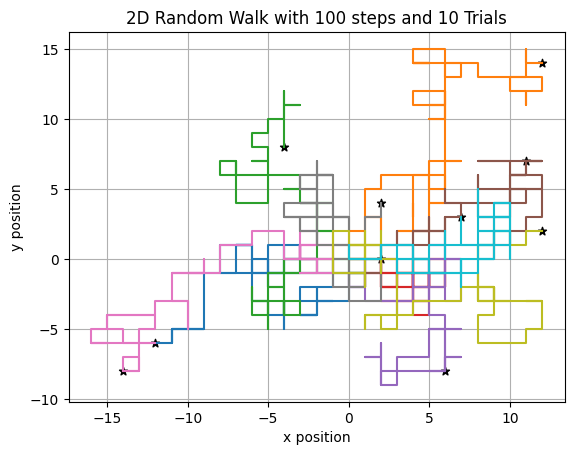

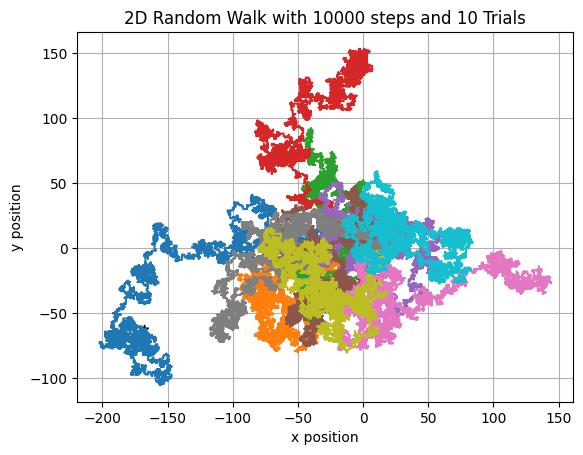

In [ ]:
def randomwalk2d(N): #Defining a function to generate an array of all movements that a particle makes in N steps.
    xsteps = np.zeros(N) #Initializing the x position and y position arrays to follow their movement in a faster way than appending
    ysteps = np.zeros(N)

    x_or_y = rng.choice([1, 2], size=N) #Choosing which direction to move in a given step 1 is x and 2 is y
    direction = rng.choice([-1, 1], size=N) # Choosing to move forward or backward in that given axis

    for i in range(N): #Using the x_or_y and direction to move the particle as directed by the random numbers
        if x_or_y[i] == 1:
            xsteps[i] = direction[i]
        else:
            ysteps[i] = direction[i]

    x_positions = np.cumsum(xsteps) # Adding up the contributions of movement to track the coordinates of the particle at each step
    y_positions = np.cumsum(ysteps)

    return x_positions, y_positions

def plotrandomwalk2d(N, Ntrials): #Defining a function to create scatter plots of all the final positions of particles randomly moving N steps in 2D over Ntrials trials
    for trial in range(Ntrials):
        x, y = randomwalk2d(N)
        plt.plot(x, y)  #Plotting each randomwalks path
        plt.scatter(x[-1], y[-1], color='black', marker='*') #Ending each path with a black star
        plt.xlabel("x position")
        plt.ylabel("y position")
        plt.title(f"2D Random Walk with {N} steps and {Ntrials} Trials")
        plt.grid(True)
    plt.show()

plotrandomwalk2d(100,10)
plotrandomwalk2d(10000,10)


B. (5 pts) As you did for the 1D walk, stop visualizing each walk, and instead run Ntrials = 1000
random walks of N steps for N = 100 &10,000, and record the final position of each separate
walk. Show these end positions as points on a (x,y) graph. How are these points distributed about
the origin?

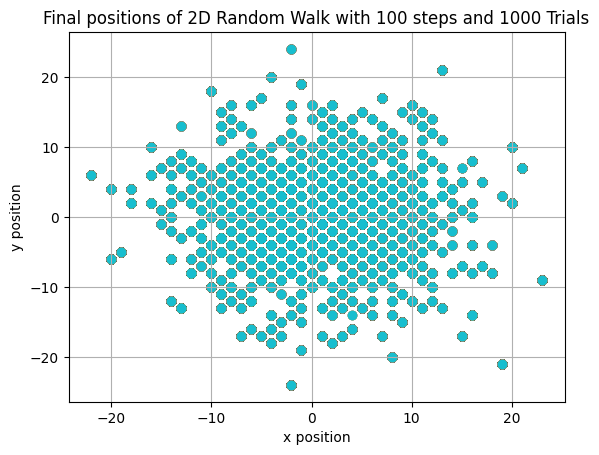

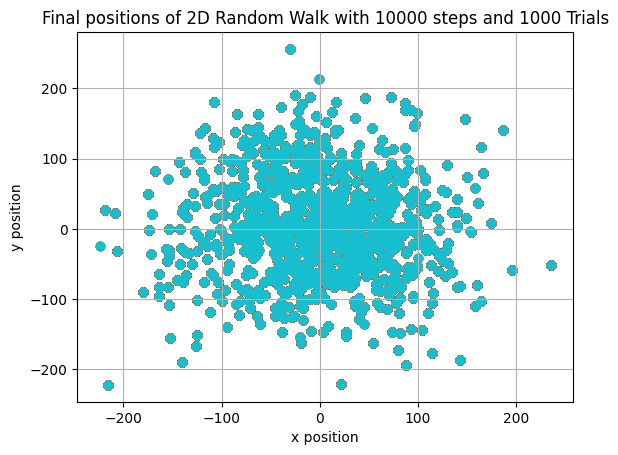

In [ ]:
def randomwalk2dfinalplot(N, Ntrials): #Defining a function to generate the final position of all movements that a particle makes in N steps Ntrials times with a histogram
    xfinalpositions = []
    yfinalpositions = []
    for trial in range(Ntrials): #Running the randomwalk function from earlier Ntrials times in order to add the final position to an array of all final positions
        xpositions, ypositions = randomwalk2d(N)
        xfinalpositions.append(float(xpositions[-1])), yfinalpositions.append(float(ypositions[-1])) #Adding the last entry of each run to an array of all the total final positions
        plt.scatter(xfinalpositions, yfinalpositions) #Plotting all the final positions
        plt.xlabel("x position")
        plt.ylabel("y position")
        plt.title(f"Final positions of 2D Random Walk with {N} steps and {Ntrials} Trials")
        plt.grid(True)
    plt.show()
    return(xfinalpositions, yfinalpositions)

answer1 = randomwalk2dfinalplot(100, 1000)
answer2 = randomwalk2dfinalplot(10000, 1000)

C. (5 pts) Generate a histogram of the final distance r = √x
2 + y
2 of the walker from the origin.
Choose the number of bins to make your graph look good. What kind of distribution do you see?
Compare this to the separate distributions for x positions and y positions of the end points.

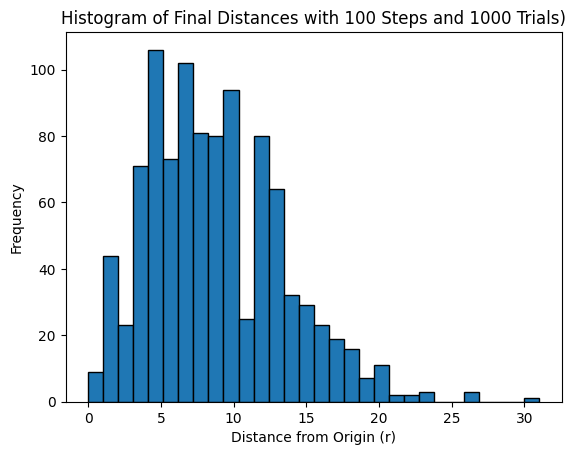

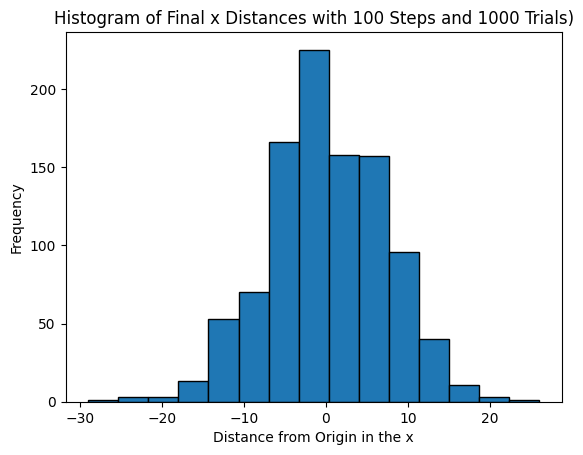

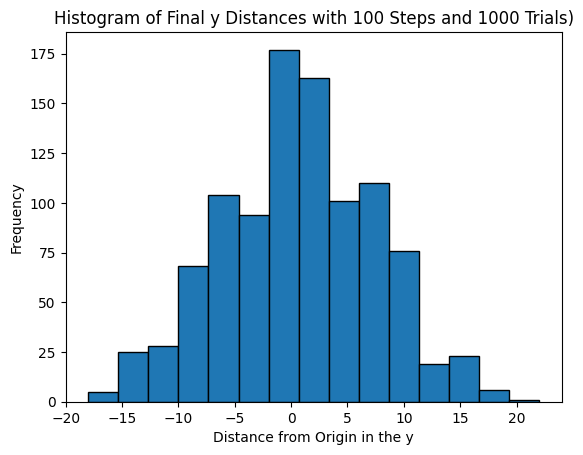

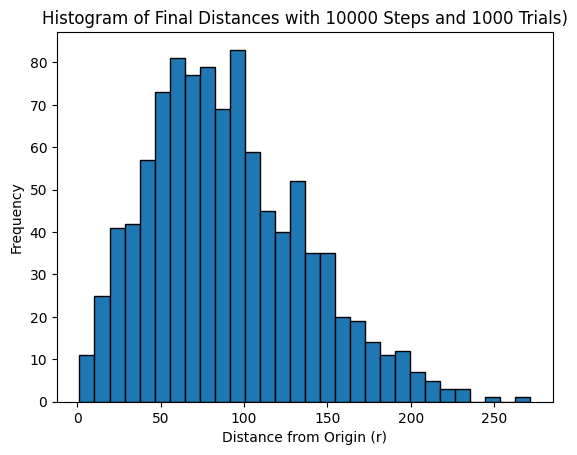

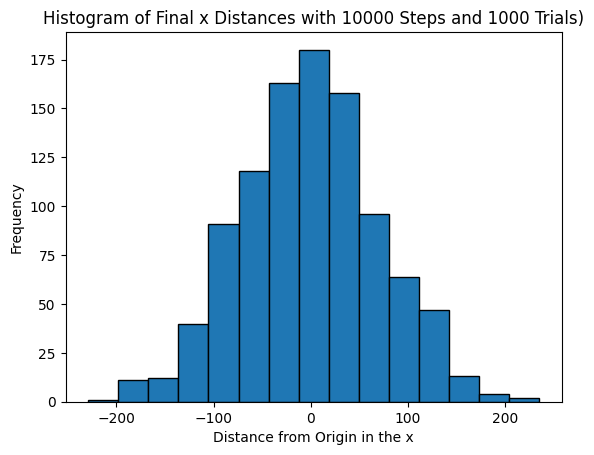

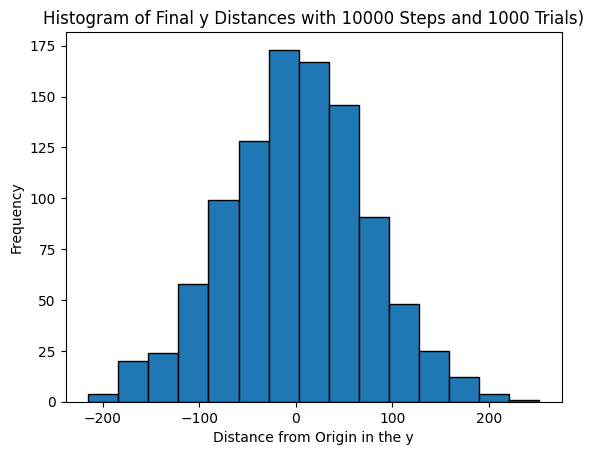

In [ ]:
def randomwalk2dfinal(N, Ntrials): #Defining a function to generate the final position of all movements that a particle makes in N steps Ntrials times
    xfinalpositions = []
    yfinalpositions = []
    for trial in range(Ntrials): #Running the randomwalk function from earlier in Ntrials times in order to add the final position to an array of all final positions
        xpositions, ypositions = randomwalk2d(N)
        xfinalpositions.append(float(xpositions[-1])), yfinalpositions.append(float(ypositions[-1]))
    return(np.array(xfinalpositions), np.array(yfinalpositions)) #Returning the final positions of x and y for all trials as an np.array in order to manipulate easier later

def rhist(N, Ntrials): #Defining a function to generate the final position of all movements that a particle makes in N steps Ntrials times with a histogram

    xfinalpositions, yfinalpositions = randomwalk2dfinal(N, Ntrials)
    
    distances = np.sqrt(xfinalpositions**2 + yfinalpositions**2) #Calculate the distance from the origin for each final position

    plt.hist(distances, bins=30, edgecolor='black') #Creating the Histogram of distances
    plt.title(f"Histogram of Final Distances with {N} Steps and {Ntrials} Trials)")
    plt.xlabel("Distance from Origin (r)")
    plt.ylabel("Frequency")
    plt.show()
    plt.hist(xfinalpositions, bins=15, edgecolor='black') #Creating the Histogram of finalx
    plt.title(f"Histogram of Final x Distances with {N} Steps and {Ntrials} Trials)")
    plt.xlabel("Distance from Origin in the x")
    plt.ylabel("Frequency")
    plt.show()
    plt.hist(yfinalpositions, bins=15, edgecolor='black') #Creating the Histogram of finaly
    plt.title(f"Histogram of Final y Distances with {N} Steps and {Ntrials} Trials)")
    plt.xlabel("Distance from Origin in the y")
    plt.ylabel("Frequency")
    plt.show()

rhist(100, 1000)
rhist(10000, 1000)

D. (5 pts) Calculate the mean and root mean square (rms) displacement from the origin for N = 100
and 10000
. Do you see a pattern in the mean and rms displacement values? How does this compare
with your 1D results? Discuss in a markdown cell.

In [ ]:
def r2d(N, Ntrials): #Using the defined function above to just calculate r (distance)

    xfinalpositions, yfinalpositions = randomwalk2dfinal(N, Ntrials)
    
    distances = np.sqrt(xfinalpositions**2 + yfinalpositions**2)
    return(distances)

firstrandomwalk2d = r2d(100,1000) #Getting all the final positions for the 1000 trials of 100 steps
firstanswer2d = (np.mean(firstrandomwalk2d)) #Calculating the mean of all final positions
firstanswerrms2d = (np.sqrt(np.mean(np.square(firstrandomwalk2d)))) #Calculating the root mean square of all the final positions
print(f"The mean of 100 Steps and 1000 Trials is {firstanswer2d} with an rms of {firstanswerrms2d}")

secondrandomwalk2d = r2d(10**4, 1000) #Repeating for 1000 trials and 10000 steps
secondanswer2d = (np.mean(secondrandomwalk2d))
secondanswerrms2d = (np.sqrt(np.mean(np.square(secondrandomwalk2d))))
print(f"The mean of 10000 Steps and 1000 Trials is {secondanswer2d} with an rms of {secondanswerrms2d}")


The mean of 100 Steps and 1000 Trials is 9.075350605580297 with an rms of 10.14199191480648
The mean of 10000 Steps and 1000 Trials is 88.43968786458188 with an rms of 99.7160468530517


The mean stays near 0 as expected by the gaussian distribution surrounding 0 for the histogram of all final positions of many trials, however, with greater amounts of steps it seems to be getting progressively further away. This is almost consistent with our shape of the distribution of the endpoints. As we add more steps, there is some kind of "floating" away from the origin that happens, making our distance from the origin greater than 0. Also there is a positive bias as all the r values are positive. The pattern in the rms is that they are almost exactly the square root of the number of steps taken. The rms also seems consistent with the histograms as it captures around 1 standard deviation from the mean of each graph! As Ntrials changes, the mean stays very roughly near the origin (with distances expanding as more steps are added) differing from the 1D case, whereas the rms changes to approximate the square root of Ntrials as it did in the 1D case as well.

E. (for 10 extra credit points) Repeat B – D for a a two-dimensional random walk that is no longer
on a square grid. Instead, the particle starts at the origin and can move one step of length r
drawn from a normal distribution: r = rng.normal() and angle relative to the x-axis
distributed randomly between 0 and 2pi: theta = 2*pi*rng.random(). How do these
compare with your results for the walk on a square lattice? Discuss in a markdown cell.

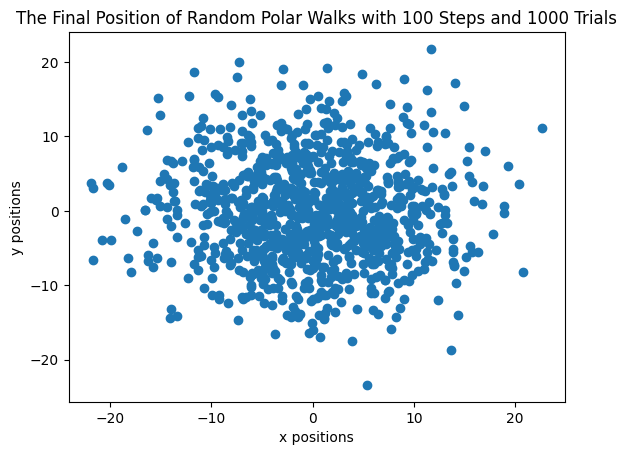

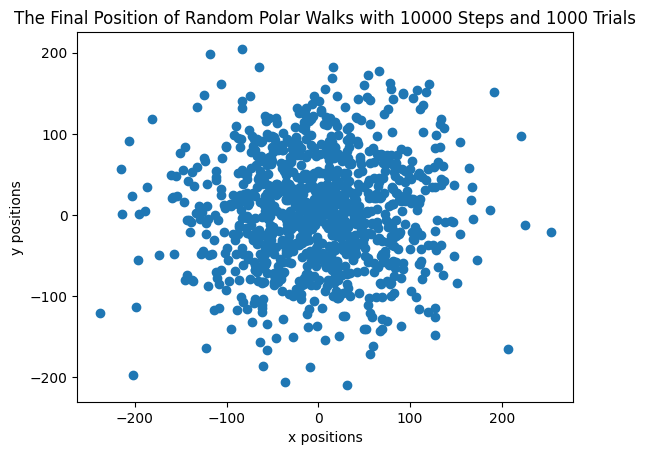

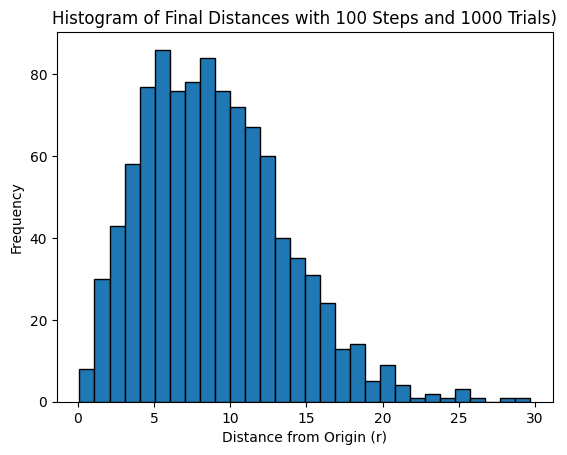

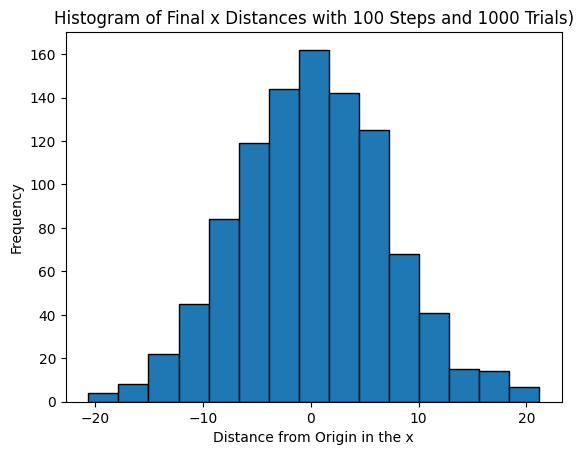

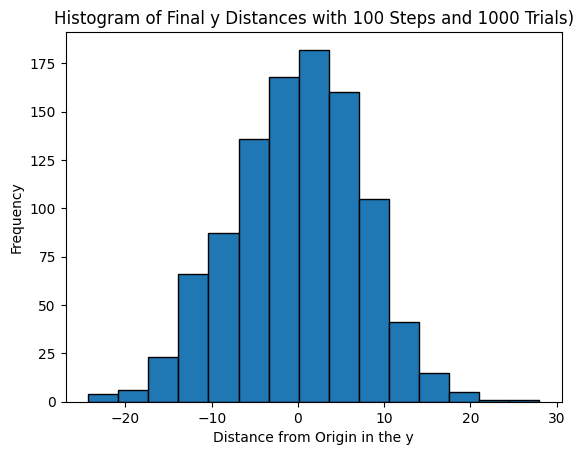

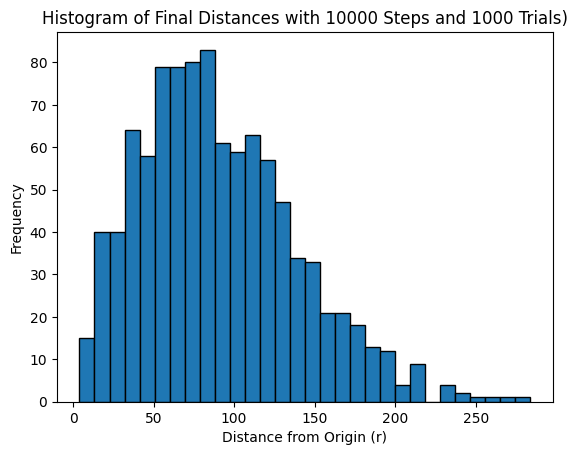

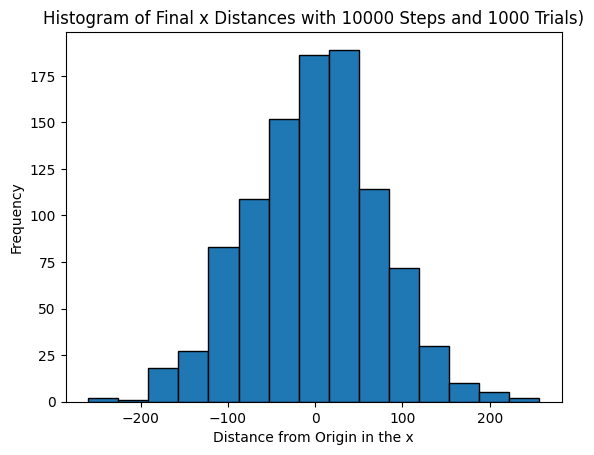

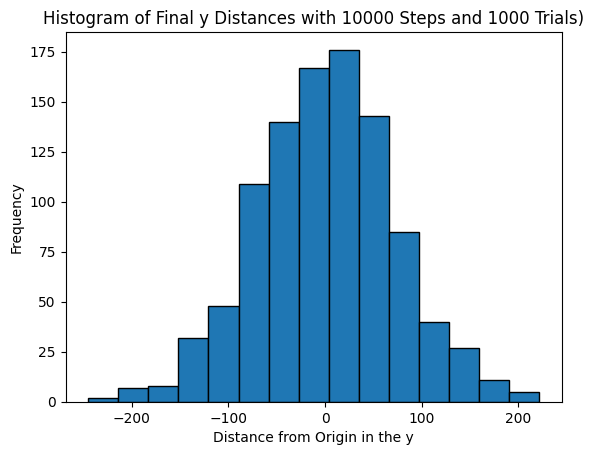

The mean of 100 Steps and 1000 Trials is 8.768085451594462 with an rms of 9.938783847781906
The mean of 10000 Steps and 1000 Trials is 88.09804571037566 with an rms of 98.80696252379799


In [ ]:
def randompolarwalk(N): #Defining a randomwalk using the polar definitions given with N steps
    r = rng.normal(size = N)
    theta = 2* np.pi * rng.random(size = N)
    x = r*np.cos(theta) #Converting the polar walk to cartesian coordinates for easier manipulation and plotting
    y = r*np.sin(theta)
    xpositions = np.insert(np.cumsum(x), 0, 0) #Adding all contributions from each random step added
    ypositions = np.insert(np.cumsum(y), 0, 0)
    return xpositions, ypositions

# B

def randompolarplotfinal(N, Ntrials): #Defining a function for the final positions of Ntrials polar randomwalks with N steps
    finalx = [] #Initializing the arrays that will hold all final positions in each dimension for the new walk added
    finaly = []
    for i in range(Ntrials):
        x, y = randompolarwalk(N) #Using the above function to get the whole array of a walk
        finalx.append(x[-1]) #Adding the final position of the newest walk to the array of final positions
        finaly.append(y[-1])
    plt.scatter(finalx, finaly) #Graphing all final positions gained via Polar in Cartesian
    plt.title(f"The Final Position of Random Polar Walks with {N} Steps and {Ntrials} Trials") 
    plt. xlabel ("x positions") 
    plt. ylabel ("y positions")
    plt. show()
randompolarplotfinal (100, 1000) 
randompolarplotfinal (10000, 1000)

# C

def randompolarwalkfinal(N, Ntrials): #Adjusting the function above to not plot the final positions and instead just return the final position arrays
    finalx = []
    finaly = []
    for i in range(Ntrials):
        x, y = randompolarwalk(N)
        finalx.append(x[-1])
        finaly.append(y[-1])
    return(finalx, finaly)
    
def randompolarwalkhist(N, Ntrials): #Defining a function to generate a histogram of the final position of all Ntrials polar randomwalk particles in N steps

    xfinalpositions, yfinalpositions = randompolarwalkfinal(N, Ntrials)
    
    distances = np.sqrt(np.array(xfinalpositions)**2 + np.array(yfinalpositions)**2) #Calculate the distance from the origin for each final position

    plt.hist(distances, bins=30, edgecolor='black') #Creating the Histograms of distances, finalx, and finaly
    plt.title(f"Histogram of Final Distances with {N} Steps and {Ntrials} Trials)")
    plt.xlabel("Distance from Origin (r)")
    plt.ylabel("Frequency")
    plt.show()
    plt.hist(xfinalpositions, bins=15, edgecolor='black')
    plt.title(f"Histogram of Final x Distances with {N} Steps and {Ntrials} Trials)")
    plt.xlabel("Distance from Origin in the x")
    plt.ylabel("Frequency")
    plt.show()
    plt.hist(yfinalpositions, bins=15, edgecolor='black')
    plt.title(f"Histogram of Final y Distances with {N} Steps and {Ntrials} Trials)")
    plt.xlabel("Distance from Origin in the y")
    plt.ylabel("Frequency")
    plt.show()

randompolarwalkhist(100, 1000)
randompolarwalkhist(10000, 1000)

# D

def rpolar(N, Ntrials): #Defining a function that calculates all the final distances from the origin of Ntrials trials with N steps
    xfinalpositions, yfinalpositions = randompolarwalkfinal(N, Ntrials)
    distances = np.sqrt(np.array(xfinalpositions)**2 + np.array(yfinalpositions)**2)
    return(distances) #Returning an array of all the distances from all the trials

firstrandomwalkpolar = rpolar(100,1000) #Getting all the final positions for the 1000 trials of 100 steps
firstanswerpolar = (np.mean(firstrandomwalkpolar)) #Calculating the mean of all final positions
firstanswerrmspolar = (np.sqrt(np.mean(np.square(firstrandomwalkpolar)))) #Calculating the root mean square of all the final positions
print(f"The mean of 100 Steps and 1000 Trials is {firstanswerpolar} with an rms of {firstanswerrmspolar}")

secondrandomwalkpolar = rpolar(10**4, 1000) #Repeating for 1000 trials and 10000 steps
secondanswerpolar = (np.mean(secondrandomwalkpolar))
secondanswerrmspolar = (np.sqrt(np.mean(np.square(secondrandomwalkpolar))))
print(f"The mean of 10000 Steps and 1000 Trials is {secondanswerpolar} with an rms of {secondanswerrmspolar}")


The mean stays near 0 as expected by the gaussian distribution surrounding 0 for the histogram of all final positions of many trials, however, with greater amounts of steps it seems to be getting progressively further away. This is almost consistent with our shape of the distribution of the endpoints. The pattern in the rms is that they are almost exactly the square root of the number of steps taken. The rms also seems consistent with the histograms as it captures around 1 standard deviation from the mean of each graph! As Ntrials changes, the mean stays roughly near 0 (with distances expanding as more steps are added), whereas the rms changes to approximate the square root of Ntrials.

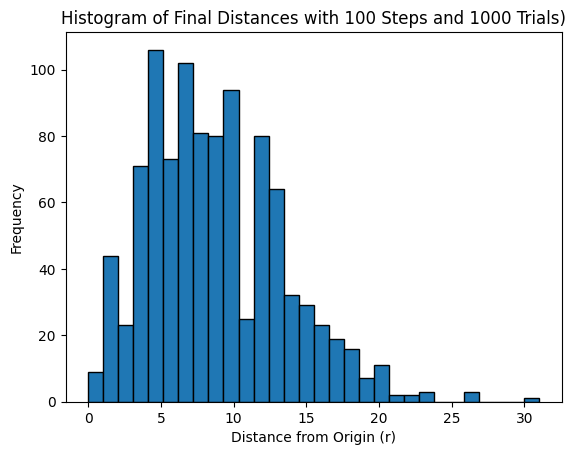

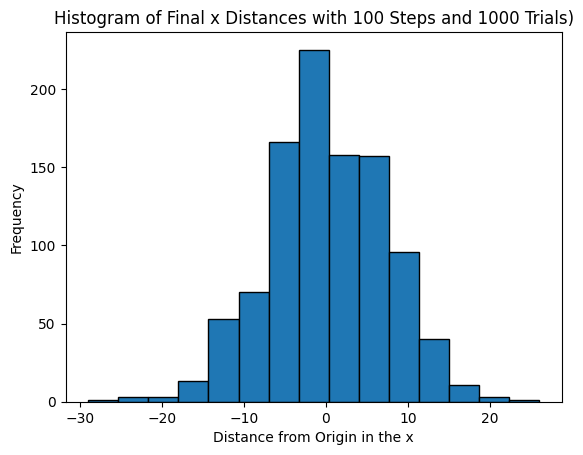

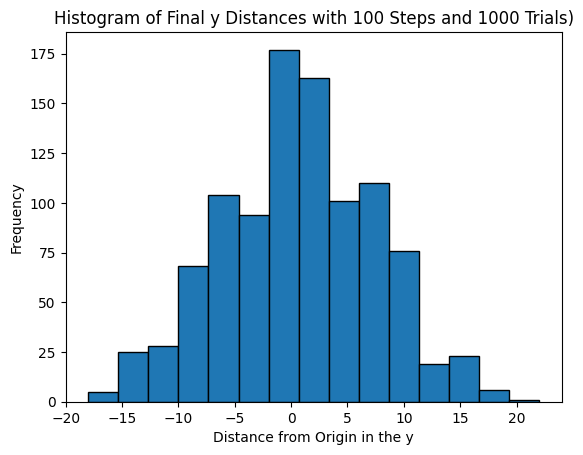

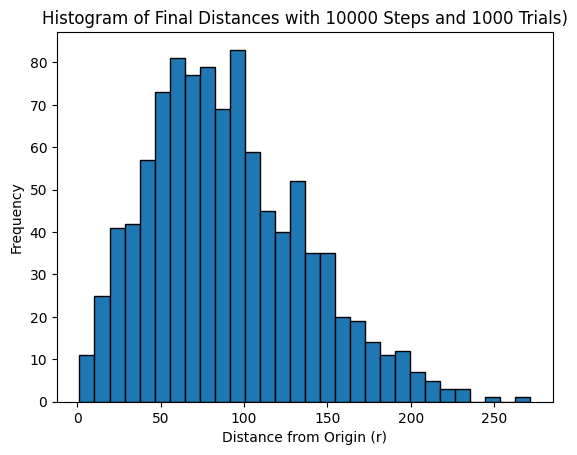

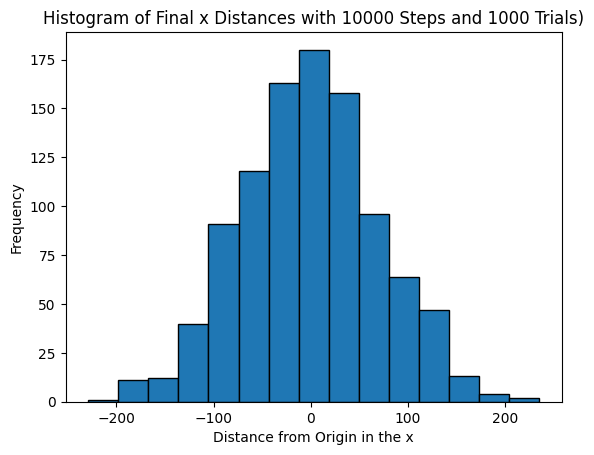

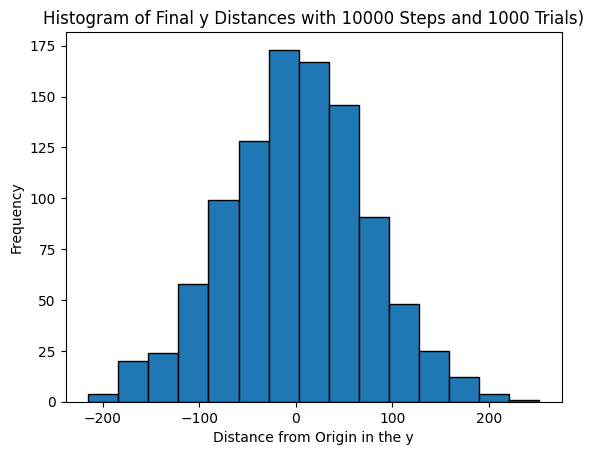

In [ ]:
def randomwalk2dfinal(N, Ntrials): #Defining a function to generate the final position of all movements that a particle makes in N steps Ntrials times
    xfinalpositions = []
    yfinalpositions = []
    for trial in range(Ntrials): #Running the randomwalk function from earlier in Ntrials times in order to add the final position to an array of all final positions
        xpositions, ypositions = randomwalk2d(N)
        xfinalpositions.append(float(xpositions[-1])), yfinalpositions.append(float(ypositions[-1]))
    return(np.array(xfinalpositions), np.array(yfinalpositions))

def rhist(N, Ntrials): #Defining a function to generate the final position of all movements that a particle makes in N steps Ntrials times with a histogram

    xfinalpositions, yfinalpositions = randomwalk2dfinal(N, Ntrials)
    
    distances = np.sqrt(xfinalpositions**2 + yfinalpositions**2) #Calculate the distance from the origin for each final position

    plt.hist(distances, bins=30, edgecolor='black') #Creating the Histograms of distances, finalx, and finaly
    plt.title(f"Histogram of Final Distances with {N} Steps and {Ntrials} Trials)")
    plt.xlabel("Distance from Origin (r)")
    plt.ylabel("Frequency")
    plt.show()
    plt.hist(xfinalpositions, bins=15, edgecolor='black')
    plt.title(f"Histogram of Final x Distances with {N} Steps and {Ntrials} Trials)")
    plt.xlabel("Distance from Origin in the x")
    plt.ylabel("Frequency")
    plt.show()
    plt.hist(yfinalpositions, bins=15, edgecolor='black')
    plt.title(f"Histogram of Final y Distances with {N} Steps and {Ntrials} Trials)")
    plt.xlabel("Distance from Origin in the y")
    plt.ylabel("Frequency")
    plt.show()

rhist(100, 1000)
rhist(10000, 1000)

The mean stays near 0 as expected by the gaussian distribution surrounding 0 for the histogram of all final positions of many trials, however, with greater amounts of steps it seems to be getting progressively further away. This is almost consistent with our shape of the distribution of the endpoints. The pattern in the rms is that they are almost exactly the square root of the number of steps taken. The rms also seems consistent with the histograms as it captures around 1 standard deviation from the mean of each graph! As Ntrials changes, the mean stays roughly near 0 (with distances expanding as more steps are added), whereas the rms changes to approximate the square root of Ntrials.

Part III: Simulate a first passage process: a bounded random walk in 2D with an absorbing point.
For this part, you will use a finite two-dimensional grid where the x axis goes from -50 to +50 and the y
axis also goes from -50 to +50. The particle will start at the left edge (x, y) = (−50,0), and diffuse
around randomly till it hits the outlet/absorber in the middle of the right edge (x, y) = (+50,0), at
which instance the walk ends abruptly. As before, at each time step, the particle can move one step on
the grid in one of four possible directions: ±x or ±y with equal probability, and your simulation must
update the particle’s x and y positions accordingly. The particle will start at the origin. Note that for
this part, the number of steps of the walk is not fixed! The number of steps is something you need to
track.

Here are the modified rules for the 2D random walk. Make sure the walker does not leave the grid.

• If the particle is not at an edge, it can take a step of one grid spacing in any of four directions:
±x, ±y; these should all be equally probable.

• If the particle is at one of the edges, it cannot pass out of the box. It should have a 50%
probability of taking a step perpendicularly away from the wall, and a 25% chance of
stepping in either of the directions along the wall.

• If the particle is at a corner, it has a 50% chance of going in either of the two directions along
the walls.

• If the particle touches the absorbing point at (x, y) = (+50,0), the random walk ends.

A. (20 pts) Write a program that executes one ‘walk’ and prints out the number of steps the particle
takes before being absorbed – the residence time of our two-dimensional lake for that tracer. You
will be assessed on whether you have correctly implemented the walking rules above.

In [ ]:
def ruledrandomwalk2dsteps(): #Creating a function to count the steps until absorption
    (x, y) = (-50, 0) #Defining a 2d starting point and initializing the steps
    steps = 0

    while (x, y) != (50, 0):  # Stop at absorption point
        steps += 1 #Adding a step for each movement
        
        if x == -50 and y == -50:  # Movement for bottom left corner
            movement = rng.choice([(1, 0), (0, 1)])  
        elif x == -50 and y == 50:  # Movement for top left corner
            movement = rng.choice([(1, 0), (0, -1)]) 
        elif x == 50 and y == 50: #Movement for top right corner
             movement = rng.choice([(-1, 0), (0, -1)])
        elif x == 50 and y == -50: #Movement for bottom right corner
            movement = rng.choice([(-1, 0), (0, 1)])
        elif x == 50: #Movement for right edge
            movement = rng.choice([(-1, 0), (0, 1), (0, -1)], p=[0.5, 0.25, 0.25])  
        elif x == -50:  # Movement for left edge
            movement = rng.choice([(1, 0), (0, 1), (0, -1)], p=[0.5, 0.25, 0.25])  
        elif y == -50:  # Movement for bottom edge 
            movement = rng.choice([(0, 1), (1, 0), (-1, 0)], p=[0.5, 0.25, 0.25])  
        elif y == 50:  # Movement for top edge 
            movement = rng.choice([(0, -1), (1, 0), (-1, 0)], p=[0.5, 0.25, 0.25])  
        else:  # General case: move in any direction with equal probability
            movement = rng.choice([(1, 0), (-1, 0), (0, 1), (0, -1)])  

        x += movement[0] #Add the movement in the x direction from the ruled random movement
        y += movement[1] #Add the movement in the y direction from the ruled random movement

    return steps

# Run one simulation
steps = ruledrandomwalk2dsteps()
print(f"The particle took {steps} steps before being absorbed.")


The particle took 41460 steps before being absorbed.


B. (5 pts) Make a plot of the trajectory taken by the particle (positions in x,y).
a. Label the x and y axes appropriately, and give the plot a title b. Indicate the starting position with a black asterisk and the end position with a red asterisk.

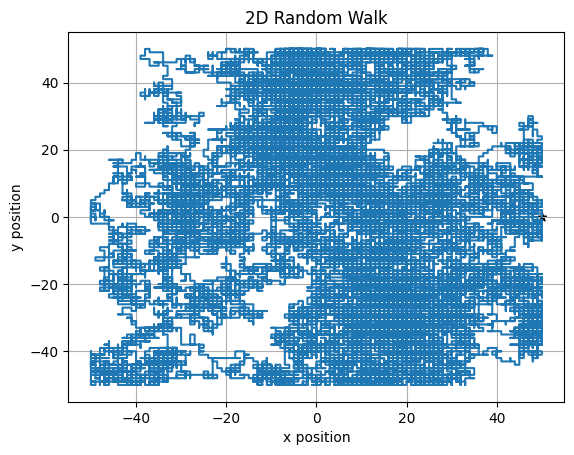

In [ ]:
def ruledrandomwalk2dplot(): #Using the function above to create arrays of x and y movements instead of steps
    (x, y) = (-50, 0) #Defining a 2d starting point and initializing the steps and arrays for storing positions
    steps = 0
    xpositions = [] 
    ypositions = []

    while (x, y) != (50, 0):  # Stop at absorption point
        steps += 1 #Adding a step for each movement

        if x == -50 and y == -50:  # Movement for bottom left corner
            movement = rng.choice([(1, 0), (0, 1)])  
        elif x == -50 and y == 50:  # Movement for top left corner
            movement = rng.choice([(1, 0), (0, -1)]) 
        elif x == 50 and y == 50: #Movement for top right corner
             movement = rng.choice([(-1, 0), (0, -1)])
        elif x == 50 and y == -50: #Movement for bottom right corner
            movement = rng.choice([(-1, 0), (0, 1)])
        elif x == 50: #Movement for right edge
            movement = rng.choice([(-1, 0), (0, 1), (0, -1)], p=[0.5, 0.25, 0.25])  
        elif x == -50:  # Movement for left edge
            movement = rng.choice([(1, 0), (0, 1), (0, -1)], p=[0.5, 0.25, 0.25])  
        elif y == -50:  # Movement for bottom edge 
            movement = rng.choice([(0, 1), (1, 0), (-1, 0)], p=[0.5, 0.25, 0.25])  
        elif y == 50:  # Movement for top edge 
            movement = rng.choice([(0, -1), (1, 0), (-1, 0)], p=[0.5, 0.25, 0.25])  
        else:  # General case: move in any direction with equal probability
            movement = rng.choice([(1, 0), (-1, 0), (0, 1), (0, -1)])  

        x += movement[0] #Add the movement in the x direction from the ruled random movement
        y += movement[1] #Add the movement in the y direction from the ruled random movement

        xpositions.append(x) #Appending the array with the new x position for this step
        ypositions.append(y) #Appending the array with the new y position for this step
    plt.plot(xpositions, ypositions)  #Plotting each randomwalks path
    plt.scatter(xpositions[0], ypositions[0], color='black', marker='*') #Starting with a black star
    plt.scatter(xpositions[-1], ypositions[-1], color='red', marker='*') #Ending with a red star
    plt.xlabel("x position")
    plt.ylabel("y position")
    plt.title(f"2D Random Walk with Absorption Point and Rules")
    plt.grid(True)
    plt.show()
ruledrandomwalk2dplot()

C. (5 pts) Expand your code so that it measures the time-to-absorption for Ntrials= 1000
independent walks. Each starts at (-50,0) and is absorbed when it hits (+50,0). For this part, you
will want to comment out or remove the part that plots the trajectory. (Start with N = 10 trials to
test your code.) Store the times in a list or an array.

In [ ]:
def ruledrandomwalk2dsteps_withtrials(Ntrials): #Creating a function to hold all of the steps of Ntrials particles with the rules of edges.
    trialsteps = []
    for trial in range(Ntrials):
        (x, y) = (-50, 0) #Defining a 2d starting point and initializing the steps
        (min, max) = (-50, 50)
        steps = 0
        while (x, y) != (50, 0):  #Stop at absorption point
            steps += 1 #Adding a step for each movement
        
            if x == min:  #Movement for left side
                if y == min: #Movement for bottom left corner
                    movement = rng.choice([(1, 0), (0, 1)])
                elif y == max: #Movement for top left corner
                   movement = rng.choice([(1, 0), (0, -1)])
                else:
                    movement = rng.choice([(1, 0), (0, 1), (0, -1)], p=[0.5, 0.25, 0.25])
            elif x == max: #Movement for right side
                if y == max: #Movement for top right corner
                    movement = rng.choice([(-1, 0), (0, -1)])
                elif y == min: #Movement for bottom right corner
                    movement = rng.choice([(-1, 0), (0, 1)])
                else:
                    movement = rng.choice([(-1, 0), (0, 1), (0, -1)], p=[0.5, 0.25, 0.25])  
            elif y == min:  # Movement for bottom edge 
                movement = rng.choice([(0, 1), (1, 0), (-1, 0)], p=[0.5, 0.25, 0.25])  
            elif y == max:  # Movement for top edge 
                movement = rng.choice([(0, -1), (1, 0), (-1, 0)], p=[0.5, 0.25, 0.25])  
            else:  # General case: move in any direction with equal probability
                movement = rng.choice([(1, 0), (-1, 0), (0, 1), (0, -1)])  

            x += movement[0] #Add the movement in the x direction from the ruled random movement
            y += movement[1] #Add the movement in the y direction from the ruled random movement
        trialsteps.append(steps)
    return trialsteps

trialsteps = ruledrandomwalk2dsteps_withtrials(1000)
print(trialsteps)


[58522, 87612, 80828, 12544, 113924, 119062, 95558, 115300, 87894, 139424, 80196, 151970, 193640, 41410, 14808, 100058, 60058, 13794, 85514, 7106, 54482, 24498, 110800, 158250, 38514, 63214, 66410, 12688, 15004, 141734, 129252, 9512, 68630, 50578, 256466, 140170, 71206, 18620, 10352, 27326, 32282, 69760, 55590, 197012, 21050, 113084, 31004, 13728, 18558, 185600, 8192, 95298, 30796, 109674, 154354, 50886, 51890, 11882, 69350, 47738, 102474, 74604, 7898, 94718, 75978, 27998, 157680, 70322, 28902, 131282, 263840, 24886, 58380, 61262, 203666, 141866, 132298, 10924, 76814, 200628, 131382, 24070, 100874, 35604, 55336, 9702, 212176, 226622, 38116, 14482, 43802, 98176, 52734, 46144, 82958, 11042, 58188, 28408, 32336, 28874, 19032, 8188, 76418, 238774, 22416, 73876, 18364, 32534, 100490, 32498, 10904, 33764, 36558, 96904, 134940, 38576, 69796, 37506, 81044, 70746, 31206, 148330, 61424, 24432, 231114, 158352, 35834, 81336, 6126, 10780, 83256, 190176, 26316, 195960, 66342, 41398, 9184, 147500, 81

D. (5 pts) Calculate and print out the mean of all the times it took your 1000 tracers to be absorbed.
This is an estimate of the average residence time.

In [285]:
print(f"{np.mean(trialsteps)}")

78169.64


E. (10 pts) Plot a histogram of the 1000 residence time results found by your code. Look up how to
generate histograms. Make sure the axes make sense and are labeled! For example, the x axis
should be “residence time”. The Y axis should be “number of occurrences”. Indicate the
location of the mean on your plot. What is the shape of the distribution? Discuss your results in
a markdown cell.

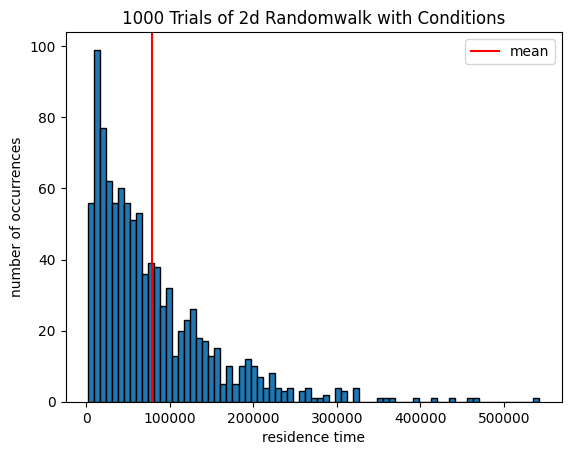

In [ ]:
plt.hist(trialsteps, bins=75, edgecolor = "black") #Plotting the histogram of all the trials stepcounts 
plt.title("1000 Trials of 2d Randomwalk with Conditions")
plt.xlabel("residence time")
plt.ylabel("number of occurrences")
plt.axvline(np.mean(trialsteps), label='mean', color='r')
plt.legend()
plt.show()

The shape of this distribution is a Rayleigh distrubution as it increases for a short time at the beginning of the graph and then skews right for the rest of the graph decreasing. As the number of steps N increases, the distribution widens, and the rms increases, causing the peak of the Rayleigh distribution to shift and the spread to become broader. 